# Zomato Data Analysis Project

# Step 1 : Importing Libraries

In [2]:
import pandas as pd                 # pandas is used for data manupulation and analysis
import numpy as np                  # numpy is used for numerical operations
import matplotlib.pyplot as plt     # matplotlib.pyplot and seaborn are used for data visualization
import seaborn as sns

# Create the data Frame

In [3]:
dataframe = pd.read_csv("Zomato data .csv")
print(dataframe)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [3]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


# Convert the data type of column - rate

In [4]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

dataframe['rate'] = dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [12]:
 dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# 1. What type of resturant do the majority of customers order from ??

# Type of  Resturant

In [13]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


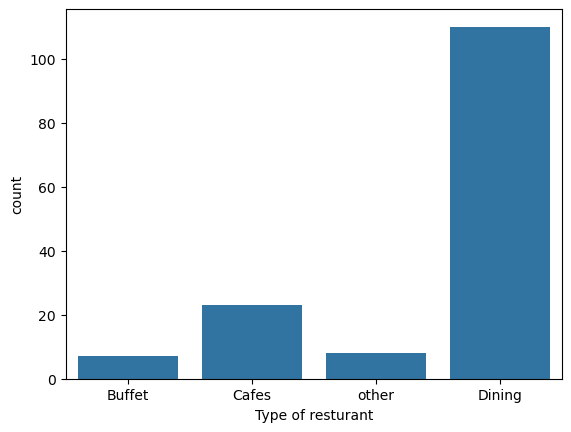

In [5]:
sns.countplot(x= dataframe["listed_in(type)"])
plt.xlabel("Type of resturant")
plt.show()

# Conclusion -- Majority of the resturant falls in dinning category

# 2. How many votes has each type of resturant received from customers ??

In [17]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


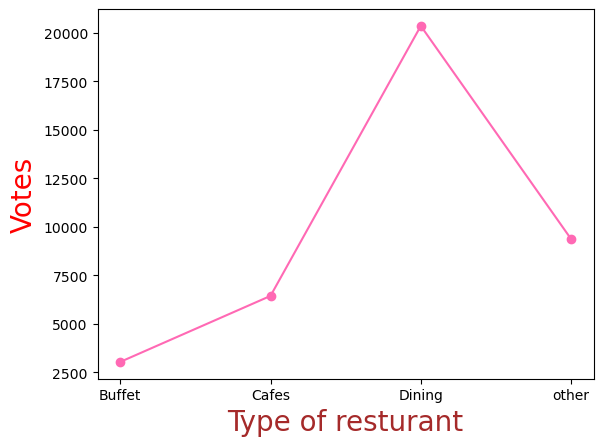

In [7]:
grouped_data = dataframe.groupby("listed_in(type)")["votes"].sum()
result = pd.DataFrame({"votes": grouped_data})
plt.plot(result, c = "hotpink", marker = "o")
plt.xlabel("Type of resturant", c = "Brown", size = 20)
plt.ylabel("Votes", c = "red", size = 20)
plt.show()

# Conclusion -- Dinnig resturants has recieved maximum votes

# 3. What are the ratings that the majority of resturants have received ??

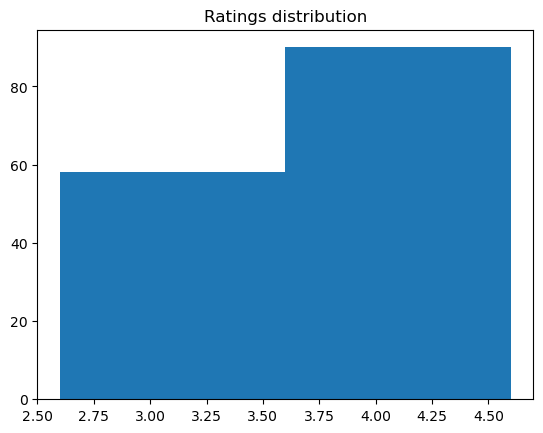

In [14]:
plt.hist(dataframe["rate"], bins = 2)
plt.title("Ratings distribution")
plt.show()

# Conclusion -- The majority resturants received ratings from 3.5 to 4.5

# 4. Zomato has observed that most couples order most of their food online. What is their average spending on each other ??

# Average order spending by couples

In [15]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


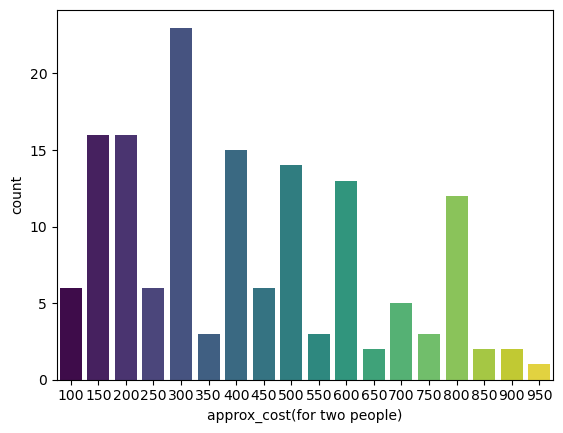

In [17]:
couple_data = dataframe["approx_cost(for two people)"]
sns.countplot(x = couple_data, hue = couple_data, palette = "viridis", legend = False )
plt.show() 

# Conclusion -- The majority of couples preferr resturants with an approximate cost of 300 rupees

# 5. Which mode (online or offline) has received the maximum ratings ??

In [18]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


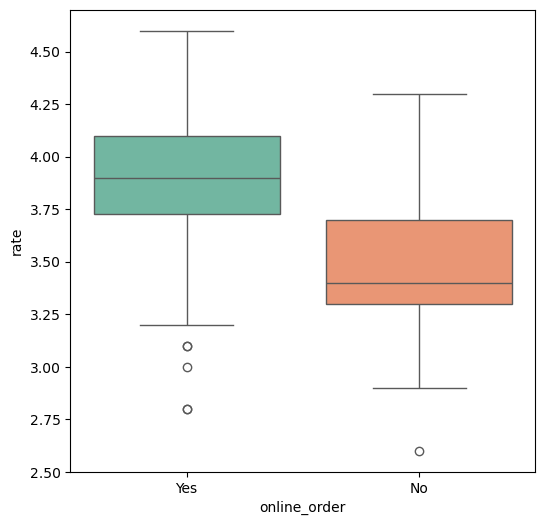

In [24]:
plt.figure(figsize = (6,6))
sns.boxplot( x = 'online_order', y = "rate", data = dataframe, hue = "online_order", palette = "Set2", legend =False)
plt.show()

# Conclusion -- Offline oder received lower rating in comparison to online order

# 6.Which type of resturant received more offline orders, so that Zomato can provide customers with some good offers ??

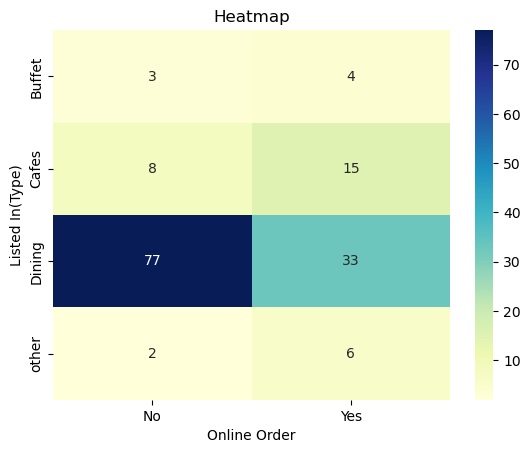

In [29]:
pivot_table = dataframe.pivot_table(index = "listed_in(type)", columns = "online_order", aggfunc = "size", fill_value = 0)
sns.heatmap(pivot_table, annot = True, cmap = "YlGnBu", fmt = "d")
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In(Type)")
plt.show()

# Conclusion -- Dinning resturants primarily accepted offline order, whereas cafes primarily receive online orders. This suggests that clients preferr order in person at resturants but prefer onlint odering at cafes.